In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
from tqdm import tqdm
import os, gc, time, shutil
import scipy.signal as ss
from pathlib import Path

In [2]:
trace_num = 2000
order = '3'
opt = 'o3'  # o0 or o3
scope = ''  # _chipwhisperer or space
algo = 'PQClean'  # orgPoly or PQClean or pqm4
platform = 'CW308_STM32F4'  # CW308_STM32F3 or CW308_STM32F4 or CWLITEARM

# 構建檔案路徑
trace_path = f'traces{scope}/{trace_num}/traces_unfixed_message_{trace_num}_{platform}_{opt}_{algo}_{order}'

t = np.load(f'{trace_path}/trace.npy')
m = np.load(f'{trace_path}/message.npy')

In [3]:
print(t.shape)
print(m.shape)
print(m)

(2000, 455000)
(2000, 32)
[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]


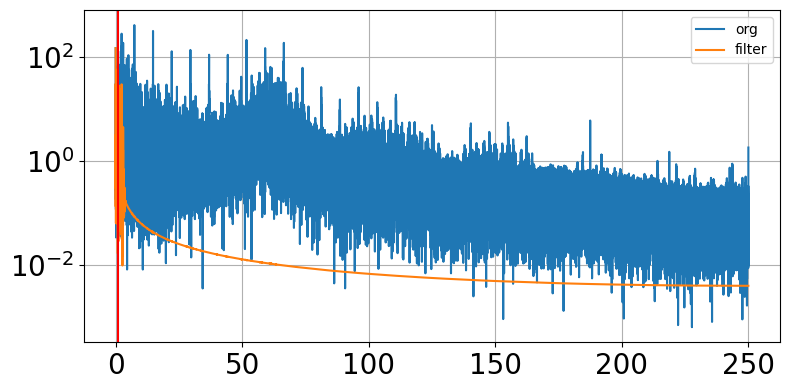

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, filtfilt

# 參數設定
fs = 500e6        # 取樣頻率 (Hz)
cutoff = 1e6     # 截止頻率 (Hz)
numtaps = 257      # 濾波器 taps 數量 (階數 = 100)

taps = firwin(numtaps, cutoff, window='hamming', fs=fs)

t_filtered = filtfilt(taps, 1.0, t, axis=1)

sig_orig = t[0]
sig_filt = t_filtered[0]
N = sig_orig.size
# 計算頻譜
freq = np.fft.rfftfreq(N, d=1/fs)
spec_orig = np.abs(np.fft.rfft(sig_orig))
spec_filt = np.abs(np.fft.rfft(sig_filt))

plt.figure(figsize=(8,4))
plt.semilogy(freq/1e6, spec_orig, label='org')
plt.semilogy(freq/1e6, spec_filt, label='filter')
plt.axvline(cutoff/1e6, color='red')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


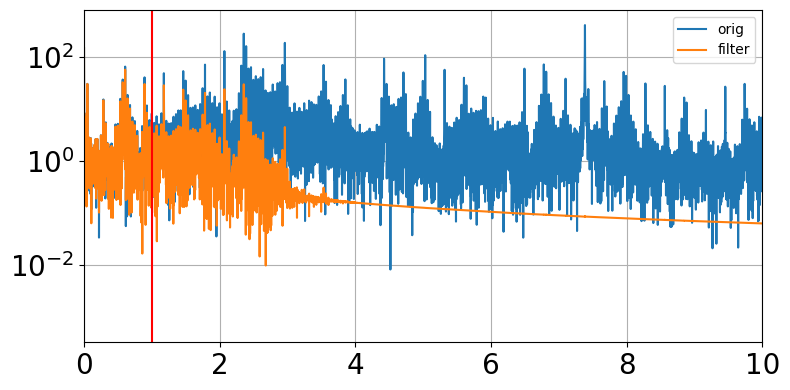

In [15]:
plt.figure(figsize=(8,4))
plt.semilogy(freq/1e6, spec_orig, label='orig')
plt.semilogy(freq/1e6, spec_filt, label='filter')
plt.axvline(cutoff/1e6, color='red')
plt.xlim(0, 10)          # 只顯示 0–10 MHz
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
print(t_filtered.shape)

(2000, 455000)


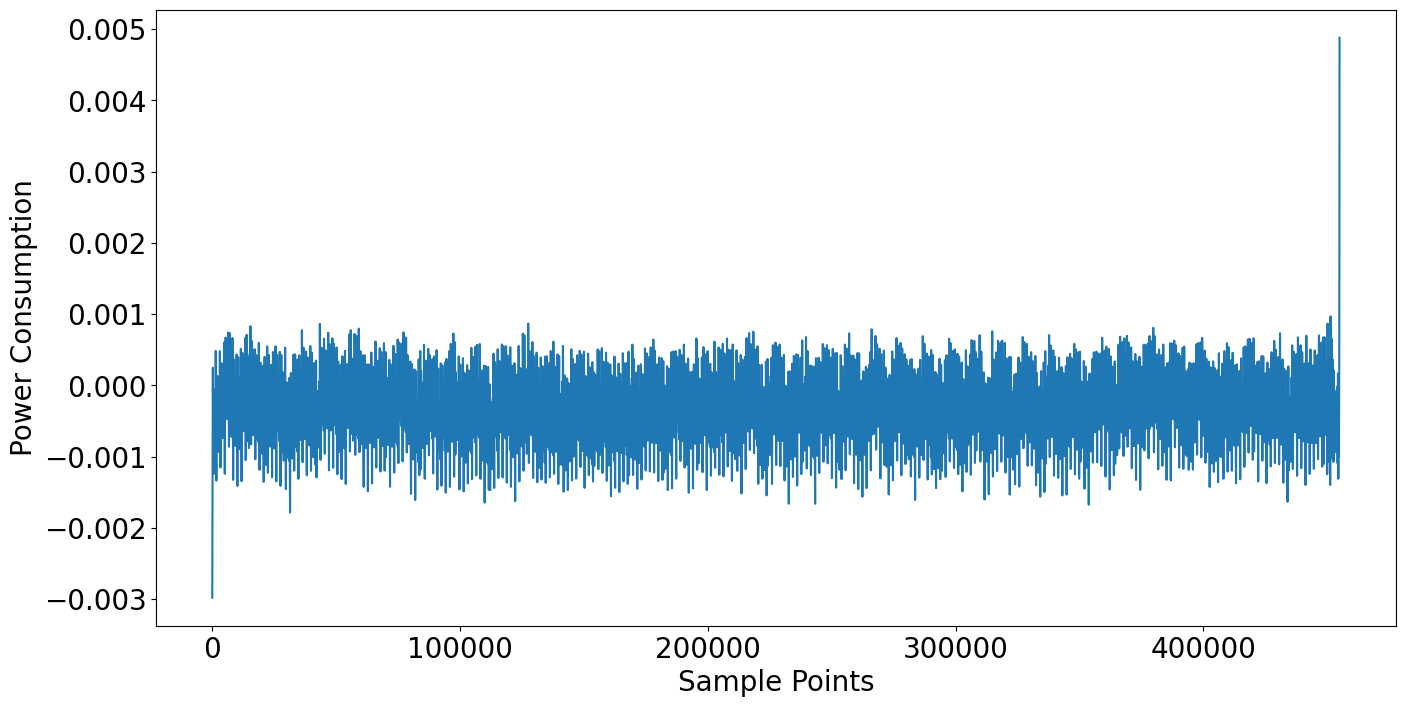

In [6]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(t_filtered[0])


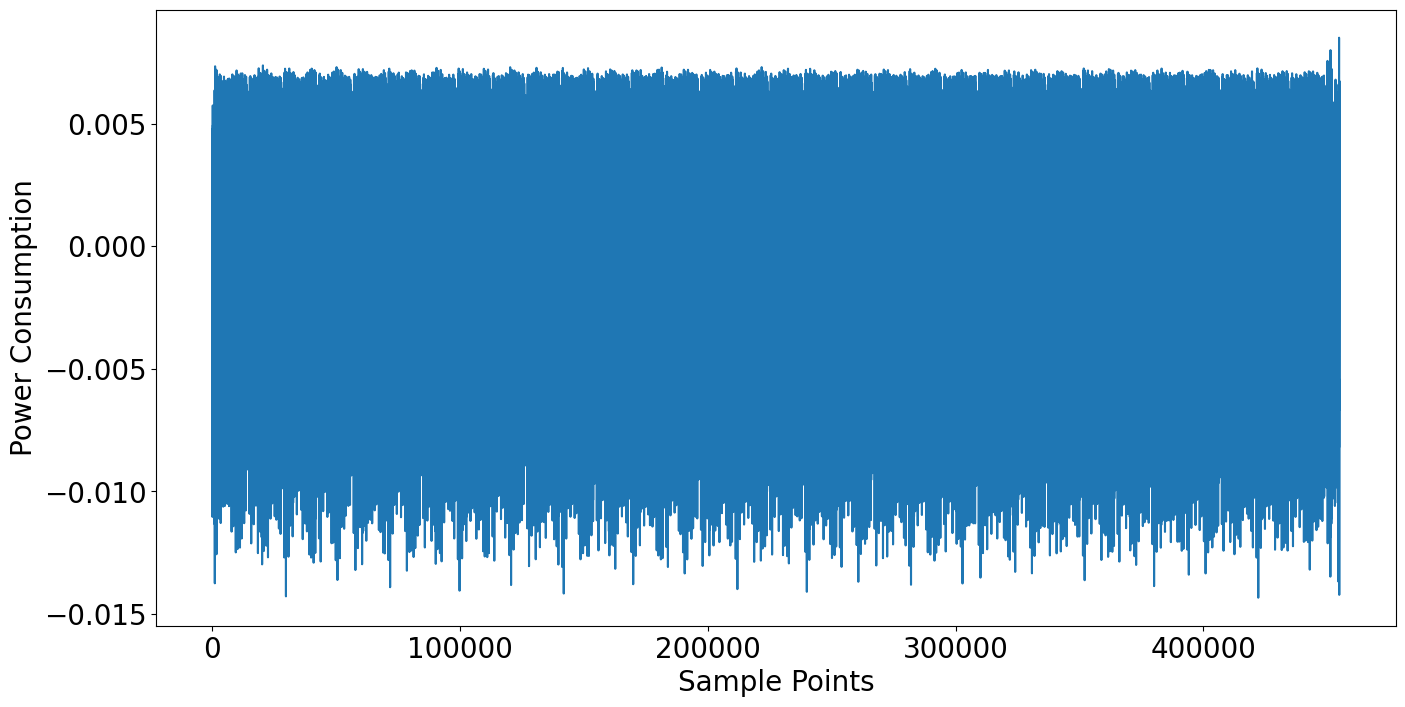

In [7]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(np.mean(t, axis=0))


In [8]:
# trace_path = f'traces_FIR/fc{cutoff}_{numtaps}'

# if not os.path.exists(trace_path):
#     os.makedirs(trace_path)
#     print(f"已創建目錄: {trace_path}")


# np.save(f'{trace_path}/trace.npy', t_filtered)
# np.save(f'{trace_path}/message.npy', m)
# print('done')